In [1]:
import scanpy as sc
import anndata as ad
import scib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os
from os.path import join
import itertools
import seaborn as sns

In [17]:

original_h5ad="/data/akalin/akollot/anglemania_benchmark/simulated/preprocessed/sce-simulated-splatter.batch.facLoc0.1_de.facLoc0.1_ngroup2_rand.h5ad"
integrated_h5ad="/data/akalin/akollot/anglemania_benchmark/simulated/integration/sce-simulated-splatter.batch.facLoc0.1_de.facLoc0.1_ngroup2/seurat/sce-simulated-splatter.batch.facLoc0.1_de.facLoc0.1_ngroup2_rand.h5ad"
outfile="test_metrics.tsv"
integration_method="seurat"
batch_key="Batch"
label_key="Group"
outfile=outfile
if os.path.exists(outfile):
    # stop and throw message
    raise FileExistsError(f"{outfile} already exists. Please delete it and try again.")
    


adata = sc.read_h5ad(original_h5ad)
adata.layers["raw_counts"] = adata.X
# the normalized expression is in adata.layers["data"]

adata_integrated = sc.read_h5ad(integrated_h5ad)

if integration_method == 'seurat':
    # apparently the SeuratDisk Convert function produces an old format of the h5ad format, so just reconstruct it
    adata_integrated.layers["raw_counts"] = adata.X
    # make category type, so that the metrics can be calculated
    adata_integrated.obs[batch_key] = adata_integrated.obs[batch_key].astype("category")
    adata_integrated.obs[label_key] = adata_integrated.obs[label_key].astype("category")
    sc.tl.pca(adata_integrated, layer="data")
    
    adata_integrated.obsm["X_emb"] = adata_integrated.obsm['X_pca']

selected_metrics = {
    'ari_' : True,
    'nmi_' : True,
    'silhouette_' : True,
    'pcr_' : True,
    'isolated_labels_' : True,
    'isolated_labels_f1_' : True,
    'isolated_labels_asw_' : True,
    'graph_conn_' : True,
    'kBET_' : True,
    'lisi_graph_' : True,
    'ilisi_' : True,
    'clisi_' : True,
    'n_cores' : 20
}

In [18]:
adata

AnnData object with n_obs × n_vars = 1000 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Cell', 'Batch', 'Group', 'ExpLibSize'
    var: 'gene_name'
    layers: 'data', 'raw_counts'

In [16]:
adata_integrated

AnnData object with n_obs × n_vars = 1000 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Cell', 'Batch', 'Group', 'ExpLibSize', 'nCount_data', 'nFeature_data', 'cluster', 'silhouette_temp'
    var: 'gene_name'
    uns: 'pca', 'neighbors', 'cluster'
    obsm: 'X_pca', 'X_emb'
    varm: 'PCs'
    layers: 'data', 'raw_counts'
    obsp: 'distances', 'connectivities'

In [6]:
adata_integrated.layers["data"]

<1000x2000 sparse matrix of type '<class 'numpy.float64'>'
	with 878514 stored elements in Compressed Sparse Column format>

In [19]:
metrics = scib.metrics.metrics(adata, adata_integrated, batch_key = batch_key, label_key = label_key, embed = 'X_emb', **selected_metrics)

/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/metrics.py:293: DeprecationWarning: Call to deprecated function (or staticmethod) opt_louvain.
  res_max, nmi_max, nmi_all = opt_louvain(


NMI...
ARI...
Silhouette score...
PC regression...


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:272: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

Variance contribution increased after integration!
Setting PCR comparison score to 0.
Isolated labels F1...
Compute neighbors on rep X_emb
Compute neighbors on rep X_emb
Isolated labels ASW...


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:272: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})


Graph connectivity...
kBET...


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will b

cLISI score...


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/metrics/lisi.py:175: UserWarning: 'batch_key' is deprecated and will be ignore
  warnings.warn("'batch_key' is deprecated and will be ignore", stacklevel=1)


iLISI score...


In [20]:
metrics #random

,0
NMI_cluster/label,0.229944
ARI_cluster/label,0.218280
ASW_label,0.508968
ASW_label/batch,0.835062
PCR_batch,0.000000
cell_cycle_conservation,NaN
isolated_label_F1,0.558932
isolated_label_silhouette,0.508925
graph_conn,1.000000
kBET,0.000000


In [13]:
metrics #hvg

,0
NMI_cluster/label,2.499277e-01
ARI_cluster/label,2.344276e-01
ASW_label,5.108072e-01
ASW_label/batch,8.634979e-01
PCR_batch,0.000000e+00
cell_cycle_conservation,NaN
isolated_label_F1,5.724929e-01
isolated_label_silhouette,5.107765e-01
graph_conn,1.000000e+00
kBET,0.000000e+00


In [10]:
metrics #angl

,0
NMI_cluster/label,0.569405
ARI_cluster/label,0.458085
ASW_label,0.524621
ASW_label/batch,0.868523
PCR_batch,0.277491
cell_cycle_conservation,NaN
isolated_label_F1,0.658099
isolated_label_silhouette,0.524584
graph_conn,1.000000
kBET,0.000000


# make meta data df for ease of use

In [7]:
datasets = ["Hao_Satija_Cell_2021_PBMC", "pbmcsca"]
gene_selections = ["hvg", "anglemania"]
integration_methods = ["harmony", "scvi", "scanvi", "seurat"]
# get unique combinations of datasets, gene selections, and integration methods
unique_combinations = list(set(itertools.product(datasets, gene_selections, integration_methods)))
meta_df = pd.DataFrame(unique_combinations, columns=["dataset", "gene_selection", "integration_method"])
meta_df["metrics_path"] = meta_df.apply(lambda x: f"/data/akalin/akollot/anglemania_benchmark/results/{x['dataset']}/{x['gene_selection']}/{x['integration_method']}_metrics.tsv", axis=1)
meta_df["integrated_h5ad"] = meta_df.apply(lambda x: f"/data/akalin/akollot/anglemania_benchmark/results/{x['dataset']}/{x['gene_selection']}/{x['integration_method']}.h5ad", axis=1)
meta_df["original_h5ad"] = meta_df.apply(lambda x: f"/data/akalin/akollot/anglemania_benchmark/data/{x['dataset']}/adata_{x['gene_selection']}.h5ad", axis=1)
for i in meta_df.original_h5ad:
    print(i)
meta_df

/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_hvg.h5ad
/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_hvg.h5ad
/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_hvg.h5ad
/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_anglemania.h5ad
/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_anglemania.h5ad
/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_hvg.h5ad
/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_hvg.h5ad
/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_anglemania.h5ad
/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_anglemania.h5ad
/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_anglemania.h5ad
/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_anglemania.h5ad
/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_anglemania.h5ad
/da

,dataset,gene_selection,integration_method,metrics_path,integrated_h5ad,original_h5ad
0,Hao_Satija_Cell_2021_PBMC,hvg,scvi,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
1,pbmcsca,hvg,harmony,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
2,pbmcsca,hvg,scvi,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
3,Hao_Satija_Cell_2021_PBMC,anglemania,scanvi,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
4,pbmcsca,anglemania,seurat,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
5,pbmcsca,hvg,seurat,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
6,Hao_Satija_Cell_2021_PBMC,hvg,seurat,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
7,pbmcsca,anglemania,scanvi,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
8,Hao_Satija_Cell_2021_PBMC,anglemania,harmony,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...
9,Hao_Satija_Cell_2021_PBMC,anglemania,scvi,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/resu...,/data/akalin/akollot/anglemania_benchmark/data...


# load metrics

In [3]:
def read_metrics(tsv_path):
    try : 
        metrics = pd.read_csv(tsv_path, sep="\t", skiprows=1, index_col=0)
        return metrics
    except:
        print(f"Error reading {tsv_path}. No such file or directory.")
        return None
    
pbmcsca_metrics = [read_metrics(f) for f in meta_df.loc[meta_df["dataset"] == "pbmcsca"]["metrics_path"]]
pbmcsca_metrics = pd.concat(pbmcsca_metrics, axis="columns")
pbmcsca_metrics = pbmcsca_metrics.drop(index=["hvg_overlap"])
# remove NA rows
pbmcsca_metrics = pbmcsca_metrics.dropna()
pbmcsca_metrics = pbmcsca_metrics.T


hao_metrics = [read_metrics(f) for f in meta_df.loc[meta_df["dataset"] == "Hao_Satija_Cell_2021_PBMC"]["metrics_path"]]
hao_metrics = pd.concat(hao_metrics, axis="columns")
# drop index HVG overlap
hao_metrics = hao_metrics.drop(index=["hvg_overlap"])
hao_metrics = hao_metrics.dropna()
hao_metrics = hao_metrics.T


# hao_metrics.index = index


Error reading /data/akalin/akollot/anglemania_benchmark/results/Hao_Satija_Cell_2021_PBMC/anglemania/seurat_metrics.tsv. No such file or directory.
Error reading /data/akalin/akollot/anglemania_benchmark/results/Hao_Satija_Cell_2021_PBMC/hvg/seurat_metrics.tsv. No such file or directory.


In [4]:
metrics = pbmcsca_metrics.sort_index()

In [5]:
metrics.style.background_gradient(cmap="Blues")

method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
harmony_anglemania,0.761405,0.731978,0.551088,0.877019,0.901008,0.753946,0.600733,0.962529,0.202659,0.367681,0.991152
harmony_hvg,0.761405,0.731978,0.551088,0.877019,0.858975,0.753946,0.600733,0.962529,0.203293,0.367694,0.990563
scanvi_anglemania,0.854376,0.825873,0.615741,0.894695,0.870049,0.864824,0.673324,0.994600,0.226871,0.428361,0.998972
scanvi_hvg,0.841485,0.795334,0.612322,0.901221,0.813794,0.933338,0.666989,0.994756,0.292479,0.446781,0.998396
scvi_anglemania,0.754852,0.675037,0.572175,0.901559,0.902953,0.828408,0.649771,0.981799,0.271702,0.452002,0.990356
scvi_hvg,0.744715,0.678708,0.571156,0.902316,0.880207,0.825748,0.639753,0.984986,0.313209,0.472486,0.987599
seurat_anglemania,0.783841,0.755292,0.596852,0.897688,0.879867,0.814992,0.659286,0.967067,0.242816,0.469035,0.995108
seurat_hvg,0.780045,0.742841,0.584737,0.890032,0.836785,0.823613,0.647789,0.973308,0.245260,0.445359,0.995883


In [6]:
# Normalize the scores within each integration method
metrics_scaled = metrics.copy()
metrics_scaled['integration_method'] = metrics_scaled.index.str.split('_').str[0]
metrics_scaled = metrics_scaled.groupby('integration_method').transform(lambda x: x/x.max())
# for each group make the plot
metrics_scaled['integration_method'] = metrics_scaled.index.str.split('_').str[0]
# Normalize the scores within each integration method

# Group by integration method and plot
metrics_scaled_grouped = metrics_scaled.groupby('integration_method')
for integration_method, group in metrics_scaled_grouped:
    display(group.drop(columns='integration_method').style.background_gradient(cmap="Blues"))

method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
harmony_anglemania,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.996884,0.999966,1.000000
harmony_hvg,1.000000,1.000000,1.000000,1.000000,0.953348,1.000000,1.000000,1.000000,1.000000,1.000000,0.999406


method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
scanvi_anglemania,1.000000,1.000000,1.000000,0.992758,1.000000,0.926593,1.000000,0.999843,0.775682,0.958770,1.000000
scanvi_hvg,0.984912,0.963023,0.994447,1.000000,0.935342,1.000000,0.990592,1.000000,1.000000,1.000000,0.999423


method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
scvi_anglemania,1.000000,0.994591,1.000000,0.999161,1.000000,1.000000,1.000000,0.996765,0.867477,0.956646,1.000000
scvi_hvg,0.986572,1.000000,0.998220,1.000000,0.974809,0.996789,0.984583,1.000000,1.000000,1.000000,0.997216


method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
seurat_anglemania,1.000000,1.000000,1.000000,1.000000,1.000000,0.989533,1.000000,0.993588,0.990033,1.000000,0.999222
seurat_hvg,0.995157,0.983515,0.979702,0.991472,0.951035,1.000000,0.982562,1.000000,1.000000,0.949521,1.000000


In [24]:
metrics["Batch"] = metrics[["ASW_label/batch", "PCR_batch", "graph_conn"]].mean(axis=1)
metrics["Bio"] = metrics[["ASW_label", "isolated_label_silhouette"]].mean(axis=1)
metrics_scaled["Batch"] = metrics_scaled[["ASW_label/batch", "PCR_batch", "graph_conn"]].mean(axis=1)
metrics_scaled["Bio"] = metrics_scaled[["ASW_label", "isolated_label_silhouette"]].mean(axis=1)

metrics.style.background_gradient(cmap="Blues")

method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI,Batch,Bio
harmony_anglemania,0.761405,0.731978,0.551088,0.877019,0.901008,0.753946,0.600733,0.962529,0.202659,0.367681,0.991152,0.913519,0.575911
harmony_hvg,0.761405,0.731978,0.551088,0.877019,0.858975,0.753946,0.600733,0.962529,0.203293,0.367694,0.990563,0.899508,0.575911
scanvi_anglemania,0.854376,0.825873,0.615741,0.894695,0.870049,0.864824,0.673324,0.994600,0.226871,0.428361,0.998972,0.919781,0.644532
scanvi_hvg,0.841485,0.795334,0.612322,0.901221,0.813794,0.933338,0.666989,0.994756,0.292479,0.446781,0.998396,0.903257,0.639656
scvi_anglemania,0.754852,0.675037,0.572175,0.901559,0.902953,0.828408,0.649771,0.981799,0.271702,0.452002,0.990356,0.928770,0.610973
scvi_hvg,0.744715,0.678708,0.571156,0.902316,0.880207,0.825748,0.639753,0.984986,0.313209,0.472486,0.987599,0.922503,0.605455
seurat_anglemania,0.783841,0.755292,0.596852,0.897688,0.879867,0.814992,0.659286,0.967067,0.242816,0.469035,0.995108,0.914874,0.628069
seurat_hvg,0.780045,0.742841,0.584737,0.890032,0.836785,0.823613,0.647789,0.973308,0.245260,0.445359,0.995883,0.900042,0.616263


## Hao

In [7]:
metrics = hao_metrics.sort_index()

In [8]:
metrics

method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
harmony_anglemania,0.738952,0.570511,0.558084,0.914142,0.560677,0.097786,0.598744,0.922733,0.829731,0.290215,0.993603
harmony_hvg,0.738952,0.570511,0.558084,0.914142,0.624666,0.097786,0.598744,0.922733,0.829381,0.289689,0.993619
scanvi_anglemania,0.795486,0.580767,0.581463,0.831457,0.550322,0.124103,0.638899,0.956621,0.764340,0.259290,0.999240
scanvi_hvg,0.820608,0.828022,0.600359,0.845465,0.578433,0.109298,0.660241,0.959663,0.803409,0.258602,0.999388
scvi_anglemania,0.736292,0.718832,0.541836,0.831920,0.417795,0.109509,0.619356,0.899521,0.765565,0.243248,0.995320
scvi_hvg,0.729696,0.622712,0.548013,0.845405,0.330185,0.083776,0.635012,0.926417,0.797657,0.239976,0.995613


In [9]:
metrics.style.background_gradient(cmap="Blues")

method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
harmony_anglemania,0.738952,0.570511,0.558084,0.914142,0.560677,0.097786,0.598744,0.922733,0.829731,0.290215,0.993603
harmony_hvg,0.738952,0.570511,0.558084,0.914142,0.624666,0.097786,0.598744,0.922733,0.829381,0.289689,0.993619
scanvi_anglemania,0.795486,0.580767,0.581463,0.831457,0.550322,0.124103,0.638899,0.956621,0.764340,0.259290,0.999240
scanvi_hvg,0.820608,0.828022,0.600359,0.845465,0.578433,0.109298,0.660241,0.959663,0.803409,0.258602,0.999388
scvi_anglemania,0.736292,0.718832,0.541836,0.831920,0.417795,0.109509,0.619356,0.899521,0.765565,0.243248,0.995320
scvi_hvg,0.729696,0.622712,0.548013,0.845405,0.330185,0.083776,0.635012,0.926417,0.797657,0.239976,0.995613


In [10]:
# Normalize the scores within each integration method
metrics_scaled = metrics.copy()
metrics_scaled['integration_method'] = metrics_scaled.index.str.split('_').str[0]
metrics_scaled = metrics_scaled.groupby('integration_method').transform(lambda x: x/x.max())
# for each group make the plot
metrics_scaled['integration_method'] = metrics_scaled.index.str.split('_').str[0]
# Normalize the scores within each integration method

# Group by integration method and plot
metrics_scaled_grouped = metrics_scaled.groupby('integration_method')
for integration_method, group in metrics_scaled_grouped:
    display(group.drop(columns='integration_method').style.background_gradient(cmap="Blues"))

method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
harmony_anglemania,1.000000,1.000000,1.000000,1.000000,0.897562,1.000000,1.000000,1.000000,1.000000,1.000000,0.999984
harmony_hvg,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.999578,0.998187,1.000000


method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
scanvi_anglemania,0.969387,0.701391,0.968526,0.983431,0.951402,1.000000,0.967675,0.996830,0.951371,1.000000,0.999852
scanvi_hvg,1.000000,1.000000,1.000000,1.000000,1.000000,0.880705,1.000000,1.000000,1.000000,0.997347,1.000000


method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI
scvi_anglemania,1.000000,1.000000,0.988728,0.984050,1.000000,1.000000,0.975344,0.970967,0.959767,1.000000,0.999706
scvi_hvg,0.991041,0.866282,1.000000,1.000000,0.790305,0.765020,1.000000,1.000000,1.000000,0.986550,1.000000


In [11]:
metrics["Batch"] = metrics[["ASW_label/batch", "PCR_batch", "graph_conn"]].mean(axis=1)
metrics["Bio"] = metrics[["ASW_label", "isolated_label_silhouette"]].mean(axis=1)
metrics_scaled["Batch"] = metrics_scaled[["ASW_label/batch", "PCR_batch", "graph_conn"]].mean(axis=1)
metrics_scaled["Bio"] = metrics_scaled[["ASW_label", "isolated_label_silhouette"]].mean(axis=1)

metrics.style.background_gradient(cmap="Blues")

method,NMI_cluster/label,ARI_cluster/label,ASW_label,ASW_label/batch,PCR_batch,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI,Batch,Bio
harmony_anglemania,0.738952,0.570511,0.558084,0.914142,0.560677,0.097786,0.598744,0.922733,0.829731,0.290215,0.993603,0.799184,0.578414
harmony_hvg,0.738952,0.570511,0.558084,0.914142,0.624666,0.097786,0.598744,0.922733,0.829381,0.289689,0.993619,0.820514,0.578414
scanvi_anglemania,0.795486,0.580767,0.581463,0.831457,0.550322,0.124103,0.638899,0.956621,0.764340,0.259290,0.999240,0.779467,0.610181
scanvi_hvg,0.820608,0.828022,0.600359,0.845465,0.578433,0.109298,0.660241,0.959663,0.803409,0.258602,0.999388,0.794520,0.630300
scvi_anglemania,0.736292,0.718832,0.541836,0.831920,0.417795,0.109509,0.619356,0.899521,0.765565,0.243248,0.995320,0.716412,0.580596
scvi_hvg,0.729696,0.622712,0.548013,0.845405,0.330185,0.083776,0.635012,0.926417,0.797657,0.239976,0.995613,0.700669,0.591513


# overlap of anglemania and hvgs

In [12]:
import upsetplot
upset = meta_df.loc[:, ["dataset", "gene_selection", "original_h5ad"]].drop_duplicates()
upset["genes"] = upset.original_h5ad.apply(lambda x: sc.read_h5ad(x).var_names.to_list())
upset.drop("original_h5ad", axis=1, inplace=True)
upset["dataset_gene_selection"] = upset.apply(lambda x: f"{x['dataset']}_{x['gene_selection']}", axis=1) # make one combined column for upset plot
upset.to_csv("../output/hvg_and_anglemania_genes.tsv", sep="\t", index=False)
upset

,dataset,gene_selection,genes,dataset_gene_selection
0,Hao_Satija_Cell_2021_PBMC,anglemania,"[RPS27, RPS29, RPL32, RPL13, RPS27A, RPS18, RP...",Hao_Satija_Cell_2021_PBMC_anglemania
1,Hao_Satija_Cell_2021_PBMC,hvg,"[HES4, TTLL10, TNFRSF18, TNFRSF4, LINC01134, A...",Hao_Satija_Cell_2021_PBMC_hvg
3,pbmcsca,anglemania,"[S100A8, S100A9, LYZ, HLA-DRA, HLA-DRB1, CST3,...",pbmcsca_anglemania
4,pbmcsca,hvg,"[AARD, ABCB1, ABLIM3, AC002331.1, AC004490.1, ...",pbmcsca_hvg


In [13]:
gene_sets = dict(zip(upset.dataset_gene_selection, upset.genes)) # make dict from df for upsetplot
gene_sets = upsetplot.from_contents(gene_sets)
gene_sets

/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


id
Hao_Satija_Cell_2021_PBMC_anglemania Hao_Satija_Cell_2021_PBMC_hvg pbmcsca_anglemania pbmcsca_hvg         
True                                 True                          False              False          RPS27
                                                                                      False          RPS29
                                     False                         False              False          RPL32
                                     True                          False              False          RPL13
                                                                                      False         RPS27A
...                                                                                                    ...
False                                False                         False              True          ZRANB3
                                                                                      True         ZSCAN20
                                                                                      True          ZSWIM3
                                                                                      True          ZSWIM4
                                                                                      True            ZW10

[6441 rows x 1 columns]

/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

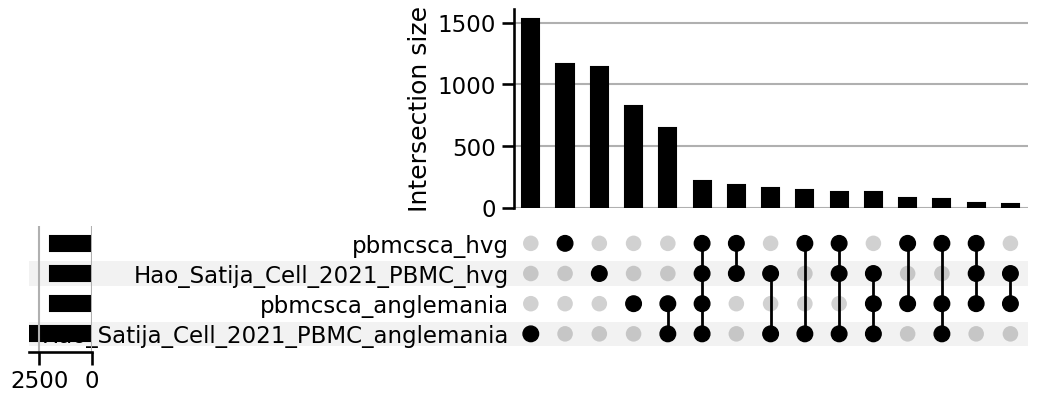

In [14]:
upset_plot = upsetplot.UpSet(gene_sets, sort_by="cardinality").plot()